### **Read The all Datasets**

In [3]:
import pandas as pd
import numpy as np
import os
import joblib
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

# 1. تحميل كافة البيانات وتجهيزها للتصنيف الثنائي
def load_binary_data(base_path):
    all_dfs = []
    for root, _, files in os.walk(base_path):
        for file in files:
            if file.endswith(('.xlsx', '.csv')):
                fp = os.path.join(root, file)
                df = pd.read_excel(fp) if file.endswith('.xlsx') else pd.read_csv(fp)
                
                t_col = next((c for c in ["textready", "text", "comment", "Text"] if c in df.columns), None)
                s_col = next((c for c in ["stars", "rating", "Star"] if c in df.columns), None)
                
                if t_col and s_col:
                    all_dfs.append(df[[t_col, s_col]].rename(columns={t_col: 'text', s_col: 'stars'}))
    
    final_df = pd.concat(all_dfs, ignore_index=True)
    
    # تحويل التقييمات إلى باينري (0 و 1)
    # 4-5 نجوم = Positive (1)
    # 1-2-3 نجوم = Negative (0) -> هكذا نضمن تدريب كامل الـ 800 ألف صف
    def to_binary(s):
        try:
            return 1 if float(s) >= 4 else 0
        except:
            return 0

    final_df['label'] = final_df['stars'].apply(to_binary)
    return final_df.dropna(subset=['text'])

# التنفيذ
path = '/kaggle/input/datasets/ziyadaltalhi/all-data-set/All Datasets For GP/Cleaned Data From Google Maps'
data = load_binary_data(path)
print(f"✅ جاهز للتدريب الثنائي على: {len(data)} صف.")

# 2. بناء الـ Pipeline الاحترافي (Hybrid: Word + Char)
# استخدام LinearSVC هو الأفضل والأسرع للـ Binary Classification الضخم
word_vec = TfidfVectorizer(ngram_range=(1, 2), max_features=80000, sublinear_tf=True)
char_vec = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), max_features=40000)

features = FeatureUnion([("word", word_vec), ("char", char_vec)])

binary_model = Pipeline([
    ("features", features),
    ("clf", LinearSVC(class_weight='balanced', random_state=42, max_iter=2000))
])

# 3. التدريب الشامل
print("⏳ جاري تدريب موديل الباينري... سيستغرق دقائق معدودة.")
binary_model.fit(data['text'].astype(str), data['label'])

# 4. الحفظ النهائي
model_name = 'svm_binary_google_maps_model.pkl'
joblib.dump(binary_model, model_name)
print(f"🎉 تم حفظ موديل الباينري بنجاح في: {model_name}")

# 5. اختبار سريع
test_text = "تجربة سيئة ولن أكررها"
pred = binary_model.predict([test_text])
res = "إيجابي" if pred[0] == 1 else "سلبي"
print(f"تجربة -> النص: '{test_text}' | النتيجة: {res}")

✅ جاهز للتدريب الثنائي على: 287349 صف.
⏳ جاري تدريب موديل الباينري... سيستغرق دقائق معدودة.
🎉 تم حفظ موديل الباينري بنجاح في: svm_binary_google_maps_model.pkl
تجربة -> النص: 'تجربة سيئة ولن أكررها' | النتيجة: سلبي


In [5]:
from sklearn.model_selection import train_test_split

# ... (بعد تحميل البيانات في المتغير data) ...

# تقسيم البيانات إلى 80% تدريب و 20% اختبار
X = data['text']
y = data['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# الآن نقوم بالتدريب على مجموعة التدريب فقط
print(f"⏳ بدء التدريب على {len(X_train)} صف...")
binary_model.fit(X_train.astype(str), y_train)

print("✅ انتهى التدريب بنجاح.")

⏳ بدء التدريب على 229879 صف...
✅ انتهى التدريب بنجاح.


⏳ جاري حساب التوقعات لتقييم الأداء...

✅ الدقة الإجمالية (Accuracy): 83.14%

📊 تقرير الأداء المفصل:
              precision    recall  f1-score   support

Negative (0)       0.61      0.73      0.67     13123
Positive (1)       0.92      0.86      0.89     44347

    accuracy                           0.83     57470
   macro avg       0.76      0.80      0.78     57470
weighted avg       0.85      0.83      0.84     57470


🖼️ مصفوفة الارتباك (Visual Confusion Matrix):


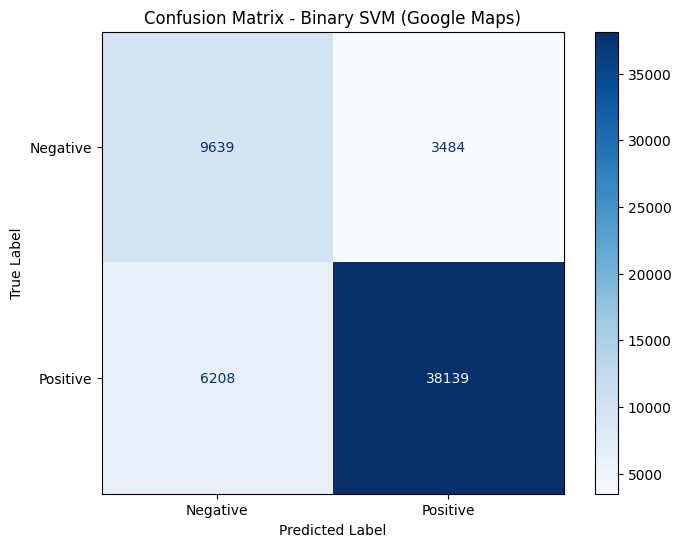

In [6]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. حساب التوقعات على مجموعة الاختبار
print("⏳ جاري حساب التوقعات لتقييم الأداء...")
y_pred = binary_model.predict(X_test.astype(str))

# 2. حساب الدقة الإجمالية
accuracy = accuracy_score(y_test, y_pred)
print(f"\n✅ الدقة الإجمالية (Accuracy): {accuracy:.2%}")

# 3. عرض تقرير التصنيف المفصل (Precision, Recall, F1-score)
print("\n📊 تقرير الأداء المفصل:")
print(classification_report(y_test, y_pred, target_names=['Negative (0)', 'Positive (1)']))

# 4. رسم مصفوفة الارتباك (Confusion Matrix) بشكل مرئي
print("\n🖼️ مصفوفة الارتباك (Visual Confusion Matrix):")
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])

# تخصيص الرسم البياني
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix - Binary SVM (Google Maps)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()